# Race-car tutorial — learning MPC cost weights end-to-end

This tutorial walks you through every object in the `race_car` example in leap-c. By the end you will understand how a Frenet-frame bicycle model is turned into an `AcadosOcp`, wrapped in a differentiable MPC planner, and used as the inner loop of a reinforcement-learning agent whose neural network outputs a *distribution over MPC cost weights* conditioned on the observation.

This file is both Sphinx-rendered documentation **and** a runnable Jupyter notebook. To use it as a notebook, install the `tutorial` extra (pulls in `jupytext` and `jupyterlab`), then convert and launch:

```bash
pip install -e .[tutorial]
jupytext --to notebook docs/source/tutorials/race_car.md
jupyter lab docs/source/tutorials/race_car.ipynb
```

The `.md` is the single source of truth; the `.ipynb` is regenerated on demand and not checked into git.

## What you will learn

1. The racing task and why it is easier in Frenet coordinates.
2. How the continuous bicycle model is encoded as a CasADi expression and shared between the simulation environment (`RaceCarEnv`) and the optimal control problem (OCP).
3. How the parametric OCP is built with a symbolic, parameter-dependent cost matrix `W = W_sqrt @ W_sqrt.T`.
4. The leap-c primitives: `AcadosParameter`, `AcadosParameterManager`, `AcadosDiffMpcTorch`, `AcadosDiffMpcCtx`, `AcadosPlanner`, `MatplotlibRenderEnv`.
5. What a **learnable differentiable parameter** actually is — and how gradients flow through the MPC solver via acados' sensitivity module.
6. How `HierachicalMPCActor` turns observations into a distribution over MPC parameters, and how SAC-ZOP and SAC-FOP optimize it.
7. How to run a closed-loop baseline lap and where to look for SAC training logs.

## Prerequisites

- leap-c installed in development mode (`pip install -e .`) from the repo root.
- acados compiled and on your library path (see {doc}`../installation`).
- The LMS track asset at `leap_c/examples/race_car/assets/LMS_Track.txt` (shipped with the repo).
- Familiarity with NumPy and (ideally) the basics of RL and optimization. You do *not* need prior acados or CasADi experience.

In [1]:
import sys

import casadi
import numpy as np
import torch

import leap_c  # noqa: F401  (ensures the package imports)
import acados_template

---

## 1. The racing task and why Frenet

We drive a small car around a closed track. The task is **one lap, as fast as possible, without leaving the corridor.** The track is given as a polyline of samples `(s, x, y, ψ, κ)` at 1 cm resolution in `LMS_Track.txt`: arc length `s`, Cartesian position `(x, y)`, tangent angle `ψ`, and signed curvature `κ`.

Racing is much easier to think about in **Frenet coordinates** aligned with the centerline. We describe the state of the car by three geometric quantities:

- `s` — arc length along the centerline (how far around the track we are),
- `n` — signed lateral offset from the centerline (how far off to the side),
- `α` — heading offset between the car and the track tangent,

plus three physical quantities:

- `v` — longitudinal speed,
- `D` — throttle / duty cycle in `[-1, 1]`,
- `δ` — steering angle in `[-0.40, 0.40]` rad.

Frenet coordinates make the corridor constraint trivial (`|n| ≤ n_max`) and let us set the reference as "be a bit farther along the track than you are now" (`s_ref = s + lookahead`). Both are awkward in Cartesian coordinates.

The formulation here follows Reiter, Nurkanović, Frey, Diehl (2023), *"Frenet-Cartesian model representations for automotive obstacle avoidance within nonlinear MPC"*, and the upstream acados `race_cars` example.

Let us load the track and look at its shape:

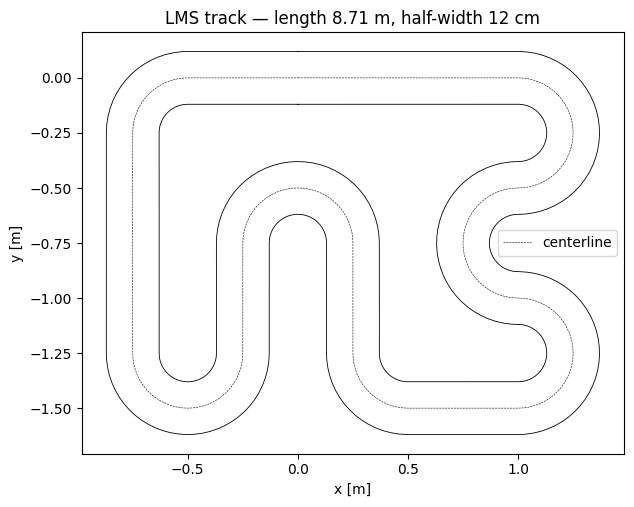

In [2]:
import matplotlib.pyplot as plt

from leap_c.examples.race_car.bicycle_model import get_track, DEFAULT_TRACK_FILE, N_MAX_DEFAULT

sref, xref, yref, psiref, kref = get_track(DEFAULT_TRACK_FILE)

nx_, ny_ = -np.sin(psiref), np.cos(psiref)
inner_x = xref + N_MAX_DEFAULT * nx_
inner_y = yref + N_MAX_DEFAULT * ny_
outer_x = xref - N_MAX_DEFAULT * nx_
outer_y = yref - N_MAX_DEFAULT * ny_

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(xref, yref, "k--", lw=0.4, label="centerline")
ax.plot(inner_x, inner_y, "k-", lw=0.6)
ax.plot(outer_x, outer_y, "k-", lw=0.6)
ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"LMS track — length {sref[-1]:.2f} m, half-width {N_MAX_DEFAULT*100:.0f} cm")
ax.legend()
plt.show()

The lap is ~6.7 m long with a half-width of 12 cm. Small track, small car (43 g).

---

## 2. The bicycle model — continuous dynamics and curvature spline

The Frenet-frame bicycle model is a 6-dimensional ODE `dx/dt = f(x, u)` with

$$
x = \begin{bmatrix} s \\ n \\ \alpha \\ v \\ D \\ \delta \end{bmatrix}, \qquad
u = \begin{bmatrix} \dot{D} \\ \dot{\delta} \end{bmatrix}.
$$

Note that `D` and `δ` are *states*, not controls — the control is their rate. This is a common trick: it lets us enforce rate limits (`|dD/dt| ≤ 10`, `|dδ/dt| ≤ 2`) as simple box constraints on `u`, while box constraints on `D, δ` become path constraints on the state.

The continuous dynamics come from `define_f_expl_expr` in `leap_c/examples/race_car/bicycle_model.py:107`. The key lines are:

```python
Fxd = (Cm1 - Cm2 * v) * D - Cr2 * v * v - Cr0 * ca.tanh(5 * v)
sdota = (v * ca.cos(alpha + C1 * delta)) / (1 - kapparef_s(s) * n)
return ca.vertcat(
    sdota,
    v * ca.sin(alpha + C1 * delta),
    v * C2 * delta - kapparef_s(s) * sdota,
    Fxd / m * ca.cos(C1 * delta),
    derD,
    derDelta,
)
```

The terms `(Cm1 - Cm2·v)·D` is motor force, `Cr2·v²` is quadratic drag, `Cr0·tanh(5v)` is a smooth approximation to rolling-resistance Coulomb friction. `(1 - κ·n)` is the Frenet Jacobian: as you move sideways on a curve, your arc-length speed scales.

Let us inspect the default vehicle parameters:

In [3]:
from leap_c.examples.race_car.bicycle_model import VEHICLE_PARAMS_DEFAULT

for k, v in VEHICLE_PARAMS_DEFAULT.items():
    print(f"  {k:4s} = {v}")

  m    = 0.043
  C1   = 0.5
  C2   = 15.5
  Cm1  = 0.28
  Cm2  = 0.05
  Cr0  = 0.011
  Cr2  = 0.006


### The curvature spline

The only input-dependent term in the dynamics is `κ(s)`. We need it as a CasADi function so the solver can differentiate through it. `build_curvature_spline` (`bicycle_model.py:87`) builds a B-spline with *wrap-around extension*, so the spline stays valid for `s < 0` (the car starts at `s = -2 m`) and for `s > pathlength` (MPC lookahead past the finish line):

In [4]:
import casadi as ca
from leap_c.examples.race_car.bicycle_model import (
    build_curvature_spline, define_f_expl_expr, f_explicit_numpy_factory,
)

kapparef_s, pathlength = build_curvature_spline()
print("pathlength =", pathlength, "m")

x_sym = ca.SX.sym("x", 6)
u_sym = ca.SX.sym("u", 2)
f_expr = define_f_expl_expr(x_sym, u_sym, kapparef_s)
print("f_expr size:", f_expr.shape)

pathlength = 8.7104967 m
f_expr size: (6, 1)


:::{note}
The dynamics blow up if `1 − κ·n = 0`. For this track (max |κ| ≈ 9.8 m⁻¹) and the corridor half-width 12 cm, this cannot happen: `κ·n` stays well under 1. A more aggressive track or wider corridor would need explicit guarding.
:::

### Numpy callable for the environment

The `RaceCarEnv` (Section 4) must integrate the same dynamics, but in pure numpy. `f_explicit_numpy_factory` compiles the CasADi expression into a numpy-callable:

In [5]:
f_numpy = f_explicit_numpy_factory()
x0 = np.array([-2.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u = np.array([5.0, 0.0])
print("dx/dt at x=init, u=[5, 0]:", f_numpy(x0, u))

dx/dt at x=init, u=[5, 0]: [0. 0. 0. 0. 5. 0.]


Both the env and the OCP now share a single source of truth for the continuous dynamics. Plant-model alignment comes for free.

---

## 3. The RK4 integrator — shared between env and OCP

To step the dynamics we need a discrete-time map `x_{k+1} = F(x_k, u_k, dt)`. Both the environment and the OCP use the classical 4-stage Runge–Kutta integrator, with the *same* `f`:

In [6]:
def rk4_step(f, x, u, h):
    k1 = f(x, u)
    k2 = f(x + 0.5 * h * k1, u)
    k3 = f(x + 0.5 * h * k2, u)
    k4 = f(x + h * k3, u)
    return x + h / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)

- The env applies this once per environment step (`dt = 0.02 s`).
- The OCP applies it per shooting stage using `leap_c.examples.utils.casadi.integrate_erk4`, which inlines the 4 stages symbolically for the solver.

Because the continuous `f` is identical, any discrepancy between env and MPC predictions comes from the integrator only (bounded `O(h⁴)`), not from structurally different models.

Let us propagate from a standstill with full throttle and check what happens:

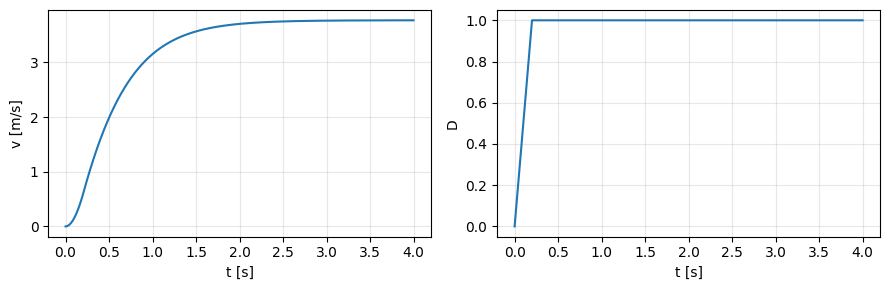

In [7]:
x = np.array([-2.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u = np.array([5.0, 0.0])  # accelerate throttle at 5 /s, no steering
dt = 0.02

ts, xs = [0.0], [x.copy()]
for _ in range(200):
    x = rk4_step(f_numpy, x, u, dt)
    # saturate D and delta to physical bounds (the env does this too)
    x[4] = np.clip(x[4], -1.0, 1.0)
    x[5] = np.clip(x[5], -0.40, 0.40)
    ts.append(ts[-1] + dt)
    xs.append(x.copy())

xs = np.asarray(xs)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(ts, xs[:, 3]); ax[0].set_xlabel("t [s]"); ax[0].set_ylabel("v [m/s]")
ax[1].plot(ts, xs[:, 4]); ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("D")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Throttle ramps up to 1 (the physical limit), then the car coasts at the equilibrium speed set by motor force vs drag.

---

## 4. The Gymnasium environment

`RaceCarEnv` (in `leap_c/examples/race_car/env.py:93`) wraps the integrator as a Gymnasium environment. It is a subclass of `MatplotlibRenderEnv`, which adds rendering utilities on top of `gym.Env`.

### Spaces and reward

| | shape | bounds | meaning |
|---|---|---|---|
| observation | `(6,)` | loose (see below) | `[s, n, α, v, D, δ]` in Frenet |
| action | `(2,)` | `[-10, 10] × [-2, 2]` | control rates `[dD/dt, dδ/dt]` |
| reward | scalar | `v · dt` | arc-length-speed × step size |

The observation-space bounds are deliberately looser than the physical limits: a wrapped policy might query the env outside the safe set during exploration, and the Gymnasium spec requires the observation to lie in the space. The env's `step` still clips actions and saturates `D, δ` to the hard box constraints internally.

Terminal conditions:

- **Terminates** when `s > pathlength` (lap complete, `info["task"]["success"] = True`).
- **Truncates** when `|n| > n_max + n_violation_margin` (off-track, `info["task"]["violation"] = True`) or after `cfg.max_steps` (default 4000 = 80 s).

Let us instantiate a race-car environment and take some random steps:

In [8]:
from leap_c.examples.race_car.env import RaceCarEnv, RaceCarEnvConfig

env = RaceCarEnv(cfg=RaceCarEnvConfig(max_steps=200), render_mode="rgb_array")
obs, _ = env.reset(seed=0)

rng = np.random.default_rng(0)
traj = [obs.copy()]
for _ in range(100):
    action = rng.uniform(low=env.action_space.low, high=env.action_space.high)
    obs, reward, term, trunc, info = env.step(action)
    traj.append(obs.copy())
    if term or trunc:
        break

traj = np.asarray(traj)
print("final obs:", obs)
print("info.task:", info["task"])
print("steps taken:", len(traj) - 1, "  |n|_max =", np.abs(traj[:, 1]).max())

final obs: [-1.02560644  0.19421468  0.64081746  1.94328905  0.60375717  0.26557643]
info.task: {'violation': True, 'success': False}
steps taken: 50   |n|_max = 0.19421468078618553


### Rendering

`MatplotlibRenderEnv` (see `leap_c/examples/utils/matplotlib_env.py:18`) calls `_render_setup` once and `_render_frame` on each `render()`. The race-car implementation draws the track corridor with arc-length markers, a velocity-colored trajectory scatter, and — if a planner `ctx` has been set via `env.set_ctx(ctx)` — the MPC plan as a dashed green line overlaid on the Cartesian view:

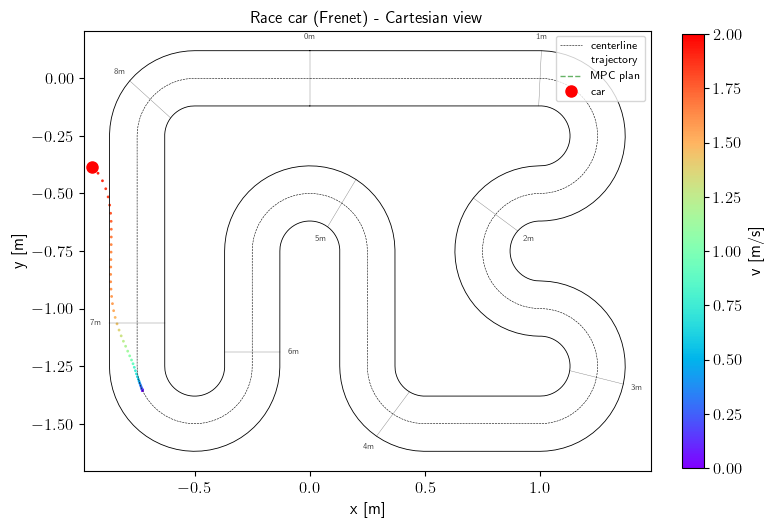

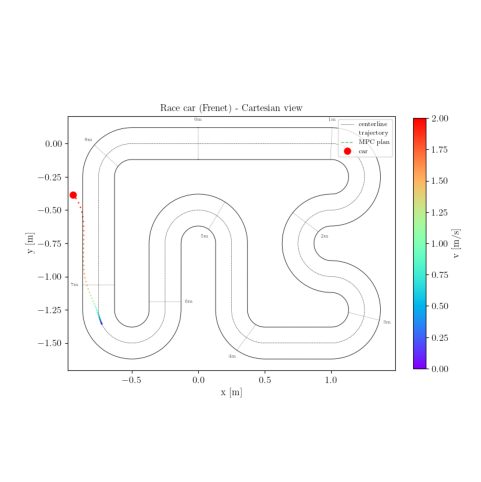

In [9]:
img = env.render()
plt.figure(figsize=(6, 6))
plt.imshow(img); plt.axis("off"); plt.show()

Random actions clearly do not drive the car anywhere useful. To do better we need a controller.

---

## 5. The OCP formulation

The optimal-control problem is built in `leap_c/examples/race_car/acados_ocp.py`. There are two responsibilities split across two functions:

1. `create_race_car_params` declares the parameters the problem depends on.
2. `export_parametric_ocp` builds the `AcadosOcp` object using those parameters.

### Problem statement

$$
\begin{aligned}
\min_{\{x_k\}, \{u_k\}} \quad & \sum_{k=0}^{N-1} \tfrac12 \| y_k - y_{\mathrm{ref},k} \|^2_{W_k} + \tfrac12 \| x_N - y_{\mathrm{ref},N} \|^2_{W_{e}} \\
\text{s.t.}\quad & x_{k+1} = F_{\mathrm{RK4}}(x_k, u_k, dt), \\
& x_0 = [-2, 0, 0, 0, 0, 0]^\top, \\
& u_k \in [-10, 10] \times [-2, 2], \\
& h(x_k, u_k) = (a_{\mathrm{long}}, a_{\mathrm{lat}}, n, D, \delta) \in [\ell, u],
\end{aligned}
$$

where `y_k = [x_k; u_k]`, `y_{\mathrm{ref},k} = [s_{\mathrm{ref},k}, 0, ..., 0]`, and `W_k, W_e` are diagonal with learnable square-root diagonals.

### The constraint set

| name | bound | stiffness |
|---|---|---|
| `derD` (control) | `[-10, 10]` 1/s | hard box |
| `derDelta` (control) | `[-2, 2]` rad/s | hard box |
| `a_long` (path) | `[-4, 4]` m/s² | **soft** (ℓ1 slack, `zl = zu = 100`) |
| `a_lat` (path) | `[-4, 4]` m/s² | hard |
| `n` (path) | `[-0.12, 0.12]` m | **soft** (ℓ1 slack, `zl = zu = 100`) |
| `D` (path) | `[-1, 1]` | hard |
| `δ` (path) | `[-0.40, 0.40]` rad | hard |

Soft constraints on `a_long` and `n` give the solver room to breathe under aggressive exploration; hard constraints on `a_lat`, `D`, `δ` keep physics faithful.

### Parameters

In [10]:
from leap_c.examples.race_car.acados_ocp import create_race_car_params

params = create_race_car_params(param_interface="global", N_horizon=50)
for p in params:
    print(f"  {p.name:15s}  interface={p.interface:13s}  shape={p.default.shape}")

  q_diag_sqrt      interface=learnable      shape=(6,)
  r_diag_sqrt      interface=learnable      shape=(2,)
  q_e_diag_sqrt    interface=learnable      shape=(6,)
  s_ref            interface=non-learnable  shape=(1,)


Three learnable parameter groups — the square roots of the diagonals of `Q`, `R`, and `Q_e` — plus one non-learnable scalar `s_ref` that the planner rewrites on each solve.

:::{tip}
**Why square roots, not the diagonals directly?** Two reasons. (i) It keeps the weights non-negative — `W = W_sqrt @ W_sqrt.T ⪰ 0` automatically, regardless of what the neural network outputs. (ii) It lets the cost be expressed as a `NONLINEAR_LS` residual, which acados solves with a Gauss-Newton Hessian. Gauss-Newton is stable and parallelism-friendly; using `EXTERNAL` cost with an exact Hessian is slower and can go indefinite.
:::

### Parameter-dependent symbolic cost

Now the magic trick that makes cost weights **learnable**. Instead of writing a numerical `W`, the OCP constructs `W` as a *symbolic* CasADi matrix whose entries depend on the learnable parameters:

```python
q_diag_sqrt   = param_manager.get("q_diag_sqrt")    # (6,) symbolic
r_diag_sqrt   = param_manager.get("r_diag_sqrt")    # (2,) symbolic
q_e_diag_sqrt = param_manager.get("q_e_diag_sqrt")  # (6,) symbolic
W_sqrt   = ca.diag(ca.vertcat(q_diag_sqrt, r_diag_sqrt))
W_e_sqrt = ca.diag(q_e_diag_sqrt)
W        = W_sqrt @ W_sqrt.T
W_e      = W_e_sqrt @ W_e_sqrt.T
```

At solve time, acados substitutes numerical values for the symbolic parameters; at *backward* time, it differentiates the solution with respect to those same symbols via the sensitivity module (see Section 9).

### Building the OCP

In [11]:
from leap_c.ocp.acados.parameters import AcadosParameterManager
from leap_c.examples.race_car.acados_ocp import export_parametric_ocp

N = 50
param_manager = AcadosParameterManager(parameters=params, N_horizon=N)
ocp = export_parametric_ocp(param_manager, N_horizon=N, T_horizon=1.0)

print("nx, nu             =", ocp.dims.nx, ocp.dims.nu)
print("integrator_type    =", ocp.solver_options.integrator_type)
print("nlp_solver_type    =", ocp.solver_options.nlp_solver_type)
print("qp_solver          =", ocp.solver_options.qp_solver)
print("cost_type / cost_type_e =", ocp.cost.cost_type, "/", ocp.cost.cost_type_e)
print("con_h_expr shape   =", ocp.model.con_h_expr.shape)
print("idxsh (soft indices) =", ocp.constraints.idxsh)

nx, nu             = 6 2
integrator_type    = DISCRETE
nlp_solver_type    = SQP_RTI
qp_solver          = PARTIAL_CONDENSING_HPIPM
cost_type / cost_type_e = NONLINEAR_LS / NONLINEAR_LS
con_h_expr shape   = (5, 1)
idxsh (soft indices) = [0 2]


Horizon: 50 stages over 1 s (each stage is `dt = 0.02 s`, matching the env step). The QP solver is partial-condensing HPIPM (Frison & Diehl 2020); the NLP loop is SQP-RTI (real-time iteration) — one QP per control step.

---

## 6. leap-c primitives tour

Step back from race_car for a moment. What leap-c actually provides, on top of acados and PyTorch, is a small set of primitives that plug a parametric OCP into an autograd graph.

### `AcadosParameter` and `AcadosParameterManager`

`AcadosParameter` (`leap_c/ocp/acados/parameters.py:13`) is a declarative record: a name, a default value, a Gymnasium `Box` for the valid range, an `interface` label (`"learnable"` / `"non-learnable"` / `"fix"`), and an optional `end_stages` list for per-stage-varying parameters. The `AcadosParameterManager` (same file, `:49`) takes a list of these and produces:

- Symbolic CasADi expressions for `ocp.model.p` (retrieved via `param_manager.get(name)` inside the OCP builder).
- A `.assign_to_ocp(ocp)` method that wires everything up.
- Helpers `combine_non_learnable_parameter_values(**kv)` and `learnable_parameters_default` for filling in numeric values at solve time.

Stagewise learnable parameters are not natively supported by acados — the manager emulates them by generating one symbolic parameter per stage block and stitching them together.

### `AcadosDiffMpcTorch`

`AcadosDiffMpcTorch` (`leap_c/ocp/acados/torch.py:19`) is a `torch.nn.Module` wrapping the `AcadosOcpBatchSolver`. Its `forward(x0, action, p_global, p_stagewise, ctx)` returns

```
(ctx, u0, x, u, value)
```

all as `torch.Tensor`s with autograd support. Under the hood it runs a custom `autograd.Function` that invokes the acados sensitivity solver on `backward`. For `NONLINEAR_LS` cost with a parameter-dependent `W`, leap-c transparently translates the cost to `EXTERNAL` form before solver creation, because acados' sensitivity interface requires an externally-defined Hessian when the cost depends on parameters.

### `AcadosDiffMpcCtx`

Each `forward` call produces an `AcadosDiffMpcCtx` (`leap_c/ocp/acados/diff_mpc.py:30`) that holds:

- `iterate` — the primal-dual solution at this step (`x`, `u`, multipliers).
- `status` — per-batch solver exit code (0 = success).
- `log` — timing and iteration counts.
- Cached sensitivity fields (`du0_dp_global`, `dvalue_dp_global`, `du0_dx0`, ...), filled on demand by `ctx.diff_mpc.sensitivity(ctx, name)`.

You pass the previous `ctx` back in on the next solve for warm-starting.

### `AcadosPlanner` and `ParameterizedController`

A *planner* returns the whole predicted trajectory plus the first action; a *controller* returns just the first action. `AcadosPlanner` (`leap_c/ocp/acados/planner.py:25`) is the standard planner built on `AcadosDiffMpcTorch`, and `ControllerFromPlanner` wraps any planner as a controller (actor-only interface).

### `MatplotlibRenderEnv`

`MatplotlibRenderEnv` (`leap_c/examples/utils/matplotlib_env.py:18`) is a small mixin over `gym.Env` that handles figure setup, `rgb_array` capture, and an optional `ctx` slot so the env can overlay the current MPC plan on its rendering.

### Diagram

```
┌──────────────────────────────────────────────────────────────────────┐
│                          Training loop (SAC)                         │
│                                                                      │
│  RaceCarEnv  ──obs──▶  HierachicalMPCActor  ──u0──▶  RaceCarEnv      │
│      ▲                          │                                    │
│      │                          │ sample param ~ π_φ(· | obs)        │
│      │                          ▼                                    │
│      │                 ControllerFromPlanner                         │
│      │                          │                                    │
│      │                          ▼                                    │
│      │                   RaceCarPlanner                              │
│      │                    (AcadosPlanner)                            │
│      │                          │                                    │
│      │                          ▼                                    │
│      │               AcadosDiffMpcTorch   ◀─── grad via KKT ────┐    │
│      │                          │                               │    │
│      │                          ▼                               │    │
│      │      AcadosOcpBatchSolver + AcadosOcpBatchSensitivity ───┘    │
│      │                          │                                    │
│      └──────────────────── action u0 ◀────────────────────────       │
└──────────────────────────────────────────────────────────────────────┘
```

TODO: Make a prettier version of this diagram with red backprop arrows and the primitives labeled on each arrow. (The red return path is the novelty: gradients of any downstream loss (critic, trajectory optimality, anything) flow back through `AcadosDiffMpcTorch` into the policy network via analytic sensitivities, not finite differences.)

### Touching the primitives directly

In [12]:
# Non-learnable parameter fill: give s_ref a different value for each stage.
s_ref_staged = np.linspace(0.0, 3.0, N + 1).reshape(1, N + 1, 1)  # (B=1, N+1, 1)
p_stagewise = param_manager.combine_non_learnable_parameter_values(s_ref=s_ref_staged)
print("p_stagewise shape:", p_stagewise.shape)

# Learnable parameter defaults flattened.
p_default = param_manager.learnable_parameters_default.cat.full().flatten()
print("learnable default shape:", p_default.shape, "   values:", np.round(p_default, 3))

p_stagewise shape: (1, 51, 1)
learnable default shape: (14,)    values: [0.316 0.    0.    0.    0.032 0.071 0.032 0.071 2.236 3.162 0.    0.
 0.071 0.045]


The 14-dimensional learnable parameter vector = `q_diag_sqrt (6) + r_diag_sqrt (2) + q_e_diag_sqrt (6)` is what the neural network in Section 10 will learn to predict from observations.

---

## 7. The planner — putting it together

`RaceCarPlanner` (`leap_c/examples/race_car/planner.py:69`) is a minimal `AcadosPlanner` subclass. Its only override is `forward`: it builds a per-stage `s_ref` from the observation and the configured lookahead, then delegates to `AcadosDiffMpcTorch`:

```python
# from planner.py
s0 = obs[:, 0:1].detach().cpu().numpy()
j  = np.arange(N + 1, dtype=np.float64).reshape(1, N + 1, 1)
s_ref_staged = s0[:, np.newaxis, :] + self.cfg.sref_lookahead * j / N

p_stagewise = self.param_manager.combine_non_learnable_parameter_values(s_ref=s_ref_staged)
if param is None:  # fill in the default learnable parameter
    param = torch.from_numpy(self.param_manager.learnable_parameters_default.cat.full().flatten())
    param = param.unsqueeze(0).expand(batch_size, -1).contiguous()
return self.diff_mpc(x0, action, param, p_stagewise, ctx=ctx)
```

So `s_ref[j] = s0 + 3.0 · j / N` — a linearly-spaced lookahead from the current arc length to 3 m ahead. This reproduces the `sref_N = 3 m` trick from the upstream acados `race_cars` example: a moving reference target that drags the car forward along the track.

Let us build a planner and solve it once at the default observation:

In [13]:
from leap_c.examples.race_car.planner import RaceCarPlanner, RaceCarPlannerConfig

planner = RaceCarPlanner(cfg=RaceCarPlannerConfig())

obs = torch.tensor([[-2.0, 0.0, 0.0, 0.0, 0.0, 0.0]], dtype=torch.float64)
with torch.no_grad():
    ctx, u0, x_plan, u_plan, value = planner(obs)

print("u0           =", u0.cpu().numpy())
print("ctx.status   =", int(ctx.status.item()))
print("x_plan shape =", tuple(x_plan.shape), "  u_plan shape =", tuple(u_plan.shape))
print("value        =", float(value.item()))
print("solve time   =", ctx.log["time_tot"], "s")

rm -f libacados_ocp_solver_race_car.so
rm -f race_car_constraints/race_car_constr_h_fun_jac_uxt_zt.o race_car_constraints/race_car_constr_h_fun.o race_car_constraints/race_car_constr_h_jac_p_hess_xu_p.o race_car_constraints/race_car_constr_h_adj_p.o race_car_cost/race_car_cost_ext_cost_0_fun.o race_car_cost/race_car_cost_ext_cost_0_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_0_fun_jac.o race_car_cost/race_car_cost_ext_cost_0_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_0_grad_p.o race_car_cost/race_car_cost_ext_cost_fun.o race_car_cost/race_car_cost_ext_cost_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_fun_jac.o race_car_cost/race_car_cost_ext_cost_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_grad_p.o race_car_cost/race_car_cost_ext_cost_e_fun.o race_car_cost/race_car_cost_ext_cost_e_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_e_fun_jac.o race_car_cost/race_car_cost_ext_cost_e_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_e_grad_p.o ./race_car_p_global

A successful solve (`status=0`) produces a 51-stage state trajectory and a 50-stage control trajectory. Let us overlay the plan on the track:

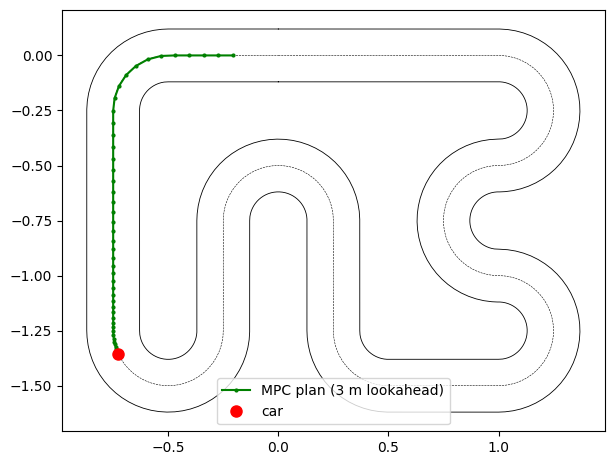

In [16]:
from leap_c.examples.race_car.bicycle_model import frenet_to_cartesian

x_plan_np = x_plan[0].detach().cpu().numpy()  # (N+1, 6)
px, py, _ = frenet_to_cartesian(x_plan_np[:, 0], x_plan_np[:, 1], sref, xref, yref, psiref)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(xref, yref, "k--", lw=0.4)
ax.plot(inner_x, inner_y, "k-", lw=0.6); ax.plot(outer_x, outer_y, "k-", lw=0.6)
ax.plot(px, py, "g.-", ms=4, label="MPC plan (3 m lookahead)")
ax.plot(px[0], py[0], "ro", ms=8, label="car")
ax.set_aspect("equal") 
ax.legend()
# ax.set_xlim(-0.6, 2.0)
# ax.set_ylim(-0.4, 0.8)
plt.show()

The plan fans out from the starting position roughly 3 m down the track — exactly the terminal `s_ref`.

---

## 8. Closed-loop verification with the baseline MPC

Before any learning, let us confirm the planner can drive the car around the full track. This is the closed-loop smoke test — identical in spirit to `scripts/race_car/run_planner_closed_loop.py` but inlined here:

In [17]:
import time

env = RaceCarEnv(cfg=RaceCarEnvConfig(max_steps=4000))
planner = RaceCarPlanner(cfg=RaceCarPlannerConfig())

obs_np, _ = env.reset(seed=0)
ctx = None
states, actions, solve_times, statuses = [obs_np.copy()], [], [], []
t_start = time.perf_counter()

for step in range(4000):
    obs_t = torch.tensor(obs_np, dtype=torch.float64).unsqueeze(0)
    t0 = time.perf_counter()
    with torch.no_grad():
        ctx, _, _, u_plan, _ = planner(obs_t, ctx=ctx)
    solve_times.append(time.perf_counter() - t0)
    statuses.append(int(ctx.status.item()))
    action = u_plan[0, 0, :].cpu().numpy().astype(np.float64)
    actions.append(action.copy())
    obs_np, _r, term, trunc, info = env.step(action)
    states.append(obs_np.copy())
    if term or trunc:
        break

states = np.asarray(states); actions = np.asarray(actions)
t = np.arange(actions.shape[0] + 1) * env.cfg.dt
print(f"Lap done in {actions.shape[0]} steps ({actions.shape[0]*env.cfg.dt:.2f} s simulated, "
      f"{time.perf_counter()-t_start:.2f} s wallclock)")
print(f"  success={info['task']['success']}, violation={info['task']['violation']}")
print(f"  v mean/max: {states[:,3].mean():.3f} / {states[:,3].max():.3f} m/s")
print(f"  solve time mean/max: {np.mean(solve_times)*1e3:.2f} / {np.max(solve_times)*1e3:.2f} ms")
print(f"  non-zero statuses: {sum(s != 0 for s in statuses)} / {len(statuses)}")

rm -f libacados_ocp_solver_race_car.so
rm -f race_car_constraints/race_car_constr_h_fun_jac_uxt_zt.o race_car_constraints/race_car_constr_h_fun.o race_car_constraints/race_car_constr_h_jac_p_hess_xu_p.o race_car_constraints/race_car_constr_h_adj_p.o race_car_cost/race_car_cost_ext_cost_0_fun.o race_car_cost/race_car_cost_ext_cost_0_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_0_fun_jac.o race_car_cost/race_car_cost_ext_cost_0_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_0_grad_p.o race_car_cost/race_car_cost_ext_cost_fun.o race_car_cost/race_car_cost_ext_cost_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_fun_jac.o race_car_cost/race_car_cost_ext_cost_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_grad_p.o race_car_cost/race_car_cost_ext_cost_e_fun.o race_car_cost/race_car_cost_ext_cost_e_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_e_fun_jac.o race_car_cost/race_car_cost_ext_cost_e_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_e_grad_p.o ./race_car_p_global

Expected outcome: ~330 steps for the full lap, zero solver failures, ~1.5 ms mean solve time on commodity hardware.

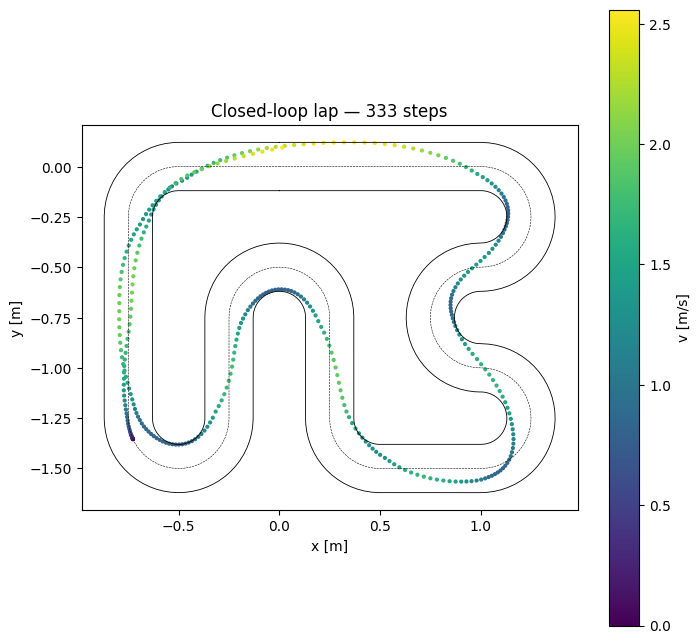

In [18]:
x_cart, y_cart, _ = frenet_to_cartesian(states[:,0], states[:,1], sref, xref, yref, psiref)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(xref, yref, "k--", lw=0.4); ax.plot(inner_x, inner_y, "k-", lw=0.6); ax.plot(outer_x, outer_y, "k-", lw=0.6)
sc = ax.scatter(x_cart, y_cart, c=states[:,3], s=4, cmap="viridis")
plt.colorbar(sc, ax=ax, label="v [m/s]")
ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"Closed-loop lap — {actions.shape[0]} steps")
plt.show()

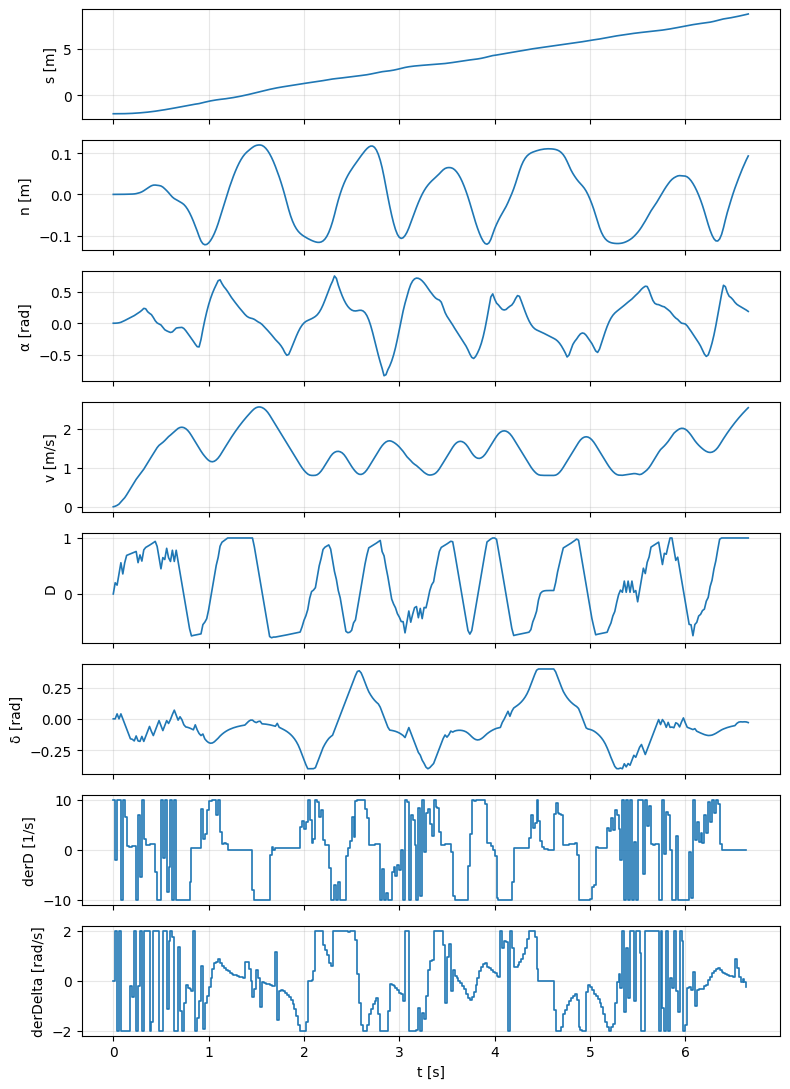

In [19]:
state_names = ["s [m]", "n [m]", "α [rad]", "v [m/s]", "D", "δ [rad]"]
action_names = ["derD [1/s]", "derDelta [rad/s]"]
fig, axes = plt.subplots(8, 1, figsize=(8, 11), sharex=True)
for i, name in enumerate(state_names):
    axes[i].plot(t, states[:, i], lw=1.2); axes[i].set_ylabel(name); axes[i].grid(alpha=0.3)
for j, name in enumerate(action_names):
    axes[6+j].step(t[:-1], actions[:, j], where="post", lw=1.2)
    axes[6+j].set_ylabel(name); axes[6+j].grid(alpha=0.3)
axes[-1].set_xlabel("t [s]"); fig.tight_layout(); plt.show()

The state trajectory shows a smooth lap: `s` rises monotonically to the pathlength, `|n|` stays well inside ±12 cm, and `v` settles near the equilibrium speed with bumps at curves.

**This is already a working controller.** The rest of the tutorial is about *making it better* — compensating for model error, learning cost weights, and so on.

---

## 9. Differentiable MPC — what "learnable parameter" means

This is the conceptual heart of the tutorial. Take it slow.

### Declarative: `interface="learnable"`

Recall the parameter declaration from Section 5:

```python
AcadosParameter(
    "q_diag_sqrt",
    default=np.sqrt(_Q_DIAG_DEFAULT),
    space=gym.spaces.Box(low=1e-6 * np.ones(6), high=1e3 * np.ones(6)),
    interface="learnable",
    end_stages=end_stages_q,
)
```

The `interface="learnable"` label tells the `AcadosParameterManager` that this parameter should be:

- exposed to the PyTorch autograd graph (input to `AcadosDiffMpcTorch.forward`),
- included in the sensitivity solve so we can ask for `∂·/∂p`.

`interface="non-learnable"` parameters (like `s_ref`) can still be changed at solve time but are *not* differentiated through — they flow as static numerical inputs only. `interface="fix"` parameters are baked into the generated C code and cannot be changed at all after solver creation.

### Operational: how gradients actually flow

The QP+NLP solution `z*(p) = (x*(p), u*(p))` is an implicit function of the parameter. At optimality, the KKT residual vanishes:

$$
F(z^*, p) = 0.
$$

Applying the implicit function theorem to this equation gives

$$
\frac{\partial z^*}{\partial p} = -\left(\frac{\partial F}{\partial z}\right)^{-1}\!\frac{\partial F}{\partial p}.
$$

`∂F/∂z` is exactly the KKT matrix that the QP solver already factorized in the forward pass; `∂F/∂p` is the derivative of the KKT residual with respect to the symbolic parameters. acados re-uses the factorization and computes `∂z*/∂p` by a single back-solve — analytic, same asymptotic cost as one QP iteration.

The practical consequence: `AcadosDiffMpcTorch.forward` returns tensors that carry gradient. When you call `.backward()` on any downstream loss, autograd invokes the sensitivity solver via a custom `autograd.Function` and hands gradients back to the parameter (and the initial state). No unrolling, no finite differences, no graph of solver iterations.

For more on this approach see Amos & Kolter (2017) *"OptNet: Differentiable Optimization as a Layer in Neural Networks"* and the acados sensitivity line of work (Frey, Diehl et al.).

### What each learnable parameter controls

| parameter | shape | role |
|---|---|---|
| `q_diag_sqrt` | (6,) | state cost weights per stage: `[w_s, w_n, w_α, w_v, w_D, w_δ]`. Higher `w_s` = harder centerline-s tracking → more aggressive lookahead chasing. |
| `r_diag_sqrt` | (2,) | control-rate cost weights: `[w_{dD}, w_{dδ}]`. Higher values smooth out throttle and steering. |
| `q_e_diag_sqrt` | (6,) | terminal state cost weights: dominates the final-stage cost → biases the entire plan toward the lookahead target. |

Training the neural network will learn how these weights should *change with the observation*: in a straight, `w_s` should be high (push forward); mid-corner, `w_n` and `w_δ` should rise (stay centered, don't oversteer); near grip-loss, `r_diag_sqrt` should rise to prevent chattering.

### Computation graph

```
obs ──▶ extractor ──▶ MLP ──▶ (μ, log σ) ──▶ sample p ──▶ AcadosDiffMpcTorch ──▶ u0 ──▶ env ──▶ reward
                                                               │                          │
                                                               │                          │
                                            ─  ∂reward/∂p analytic via KKT  ◀──  ◀── critic ◀──  ◀──
                                                               │
                                                               ▼
                                                         ∂p/∂(μ,σ)  (reparameterization)
                                                               │
                                                               ▼
                                                            MLP gradient  →  extractor  →  done
```

### Finite-difference sanity check

Let us verify the analytic sensitivity matches a finite-difference estimate. We perturb `q_diag_sqrt[0]` (the weight on `s` tracking), re-solve, and compare.

In [20]:
planner_fd = RaceCarPlanner(cfg=RaceCarPlannerConfig())

p0 = torch.from_numpy(
    planner_fd.param_manager.learnable_parameters_default.cat.full().flatten()
).unsqueeze(0).to(torch.float64)

obs = torch.tensor([[0.5, 0.05, 0.0, 1.0, 0.0, 0.0]], dtype=torch.float64)

# Analytic sensitivity via backward.
p_req = p0.clone().requires_grad_(True)
ctx, u0, *_ = planner_fd(obs, param=p_req)
loss = u0[0, 0]                     # scalar: first control component (derD)
loss.backward()
dL_dp_analytic = p_req.grad[0].clone().numpy()

# Finite difference on the same component.
eps = 1e-5
p_plus = p0.clone(); p_plus[0, 0] += eps
p_minus = p0.clone(); p_minus[0, 0] -= eps
with torch.no_grad():
    _, u_plus, *_  = planner_fd(obs, param=p_plus)
    _, u_minus, *_ = planner_fd(obs, param=p_minus)
dL_dp_fd0 = ((u_plus[0, 0] - u_minus[0, 0]) / (2 * eps)).item()

print(f"analytic ∂u0[0]/∂p[0]  = {dL_dp_analytic[0]:+.6e}")
print(f"fd       ∂u0[0]/∂p[0]  = {dL_dp_fd0:+.6e}")
print(f"relative error         = {abs(dL_dp_analytic[0] - dL_dp_fd0) / (abs(dL_dp_fd0)+1e-12):.2e}")

rm -f libacados_ocp_solver_race_car.so
rm -f race_car_constraints/race_car_constr_h_fun_jac_uxt_zt.o race_car_constraints/race_car_constr_h_fun.o race_car_constraints/race_car_constr_h_jac_p_hess_xu_p.o race_car_constraints/race_car_constr_h_adj_p.o race_car_cost/race_car_cost_ext_cost_0_fun.o race_car_cost/race_car_cost_ext_cost_0_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_0_fun_jac.o race_car_cost/race_car_cost_ext_cost_0_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_0_grad_p.o race_car_cost/race_car_cost_ext_cost_fun.o race_car_cost/race_car_cost_ext_cost_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_fun_jac.o race_car_cost/race_car_cost_ext_cost_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_grad_p.o race_car_cost/race_car_cost_ext_cost_e_fun.o race_car_cost/race_car_cost_ext_cost_e_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_e_fun_jac.o race_car_cost/race_car_cost_ext_cost_e_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_e_grad_p.o ./race_car_p_global

They match to within the SQP-RTI tolerance, confirming that the gradient you get from `.backward()` is the real derivative of the solver's solution, not a surrogate.

:::{note}
`ctx.du0_dp_global` holds the entire Jacobian `∂u0/∂p` directly if you want to look at it without going through autograd. See `leap_c/ocp/acados/diff_mpc.py:30` for the full list of cached sensitivity fields.
:::

---

## 10. The stochastic policy — `HierachicalMPCActor`

SAC requires a stochastic policy with a tractable log-probability. The race-car policy is a two-level hierarchy (`leap_c/torch/rl/mpc_actor.py:89`):

1. **High level (neural network):** observation → extractor → MLP → `(μ, log σ)` over the 14-D learnable-parameter space → squashed Gaussian.
2. **Low level (MPC):** sample `p ∼ π_φ(· | obs)`, run the deterministic planner to get `u0 = planner(obs, p)`, return it as the action.

### Configuration — parameter noise vs action noise

```python
@dataclass(kw_only=True)
class HierachicalMPCActorConfig:
    noise: Literal["param", "action"] = "param"
    extractor_name: ExtractorName = "identity"
    mlp: MlpConfig = field(default_factory=MlpConfig)
    distribution_name: BoundedDistributionName = "squashed_gaussian"
    residual: bool = False
    entropy_correction: bool = False
```

- `noise="param"` (default): the distribution is over *MPC parameters*; the MPC is run deterministically on each sample. Gradients of the critic with respect to actions must be routed through the MPC back to `p`.
- `noise="action"`: the MPC outputs a deterministic action, which is then used as the *anchor* of a distribution over actions. The MPC acts as a "prior" the policy can deviate from.
- `residual=True` (parameter mode only): predict `p = p_default + Δp`, where `Δp` is the neural-network output. Keeps training stable if the default already works.
- `entropy_correction=True` (parameter mode only): since sampling `p` and then computing `u0 = MPC(p)` is a nonlinear change of variables, the action-space entropy differs from the parameter-space entropy by `log |det J|`, where `J = ∂u0/∂p`. Enabling this subtracts the Jacobian correction from `log π(p | obs)` so SAC's entropy regularizer operates in *action* space. Off by default here because the 14 → 2 Jacobian is tall and degenerate; the plain parameter entropy works fine in practice.

### Instantiating the actor

In [21]:
import gymnasium as gym
from leap_c.torch.rl.mpc_actor import HierachicalMPCActor, HierachicalMPCActorConfig
from leap_c.torch.nn.mlp import MlpConfig
from leap_c.examples import create_controller

actor_cfg = HierachicalMPCActorConfig(
    noise="param",
    extractor_name="identity",
    mlp=MlpConfig(hidden_dims=(256, 256, 256), activation="relu", weight_init="orthogonal"),
    distribution_name="squashed_gaussian",
    residual=False,
    entropy_correction=False,
)

env_for_spaces = RaceCarEnv()
controller = create_controller("race_car")        # ControllerFromPlanner(RaceCarPlanner(...))
actor = HierachicalMPCActor(
    cfg=actor_cfg,
    observation_space=env_for_spaces.observation_space,
    action_space=env_for_spaces.action_space,
    controller=controller,
)
print(actor)

rm -f libacados_ocp_solver_race_car.so
rm -f race_car_constraints/race_car_constr_h_fun_jac_uxt_zt.o race_car_constraints/race_car_constr_h_fun.o race_car_constraints/race_car_constr_h_jac_p_hess_xu_p.o race_car_constraints/race_car_constr_h_adj_p.o race_car_cost/race_car_cost_ext_cost_0_fun.o race_car_cost/race_car_cost_ext_cost_0_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_0_fun_jac.o race_car_cost/race_car_cost_ext_cost_0_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_0_grad_p.o race_car_cost/race_car_cost_ext_cost_fun.o race_car_cost/race_car_cost_ext_cost_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_fun_jac.o race_car_cost/race_car_cost_ext_cost_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_grad_p.o race_car_cost/race_car_cost_ext_cost_e_fun.o race_car_cost/race_car_cost_ext_cost_e_fun_jac_hess.o race_car_cost/race_car_cost_ext_cost_e_fun_jac.o race_car_cost/race_car_cost_ext_cost_e_hess_xu_p.o race_car_cost/race_car_cost_ext_cost_e_grad_p.o ./race_car_p_global

### A forward pass

In [24]:
obs_batch = torch.tensor([
    [-2.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [ 1.0, 0.03, 0.1, 0.8, 0.4, 0.05],
    [ 4.0,-0.02, 0.05, 1.2, 0.6, -0.02],
], dtype=torch.float64).to(dtype=next(actor.parameters()).dtype)

out = actor(obs_batch, deterministic=False)
print("sampled param shape :", tuple(out.param.shape), "    log_prob shape:", tuple(out.log_prob.shape))
print("action shape        :", tuple(out.action.shape))
print("solver status batch :", out.status.flatten())
print("\nfirst sampled param vector (q_diag_sqrt, r_diag_sqrt, q_e_diag_sqrt):")
print(out.param[0].detach().cpu().numpy())
print("\ndefault param for comparison:")
print(planner_fd.param_manager.learnable_parameters_default.cat.full().flatten())

sampled param shape : (3, 14)     log_prob shape: (3, 1)
action shape        : (3, 2)
solver status batch : [0 0 0]

first sampled param vector (q_diag_sqrt, r_diag_sqrt, q_e_diag_sqrt):
[355.38895  537.2879   427.11264  785.41187  704.4179   974.17865
  29.344362 901.61554  172.62965  655.39874   48.388172 284.43698
 703.3235   416.95935 ]

default param for comparison:
[3.16227766e-01 1.00000000e-04 1.00000000e-04 1.00000000e-04
 3.16227766e-02 7.07106781e-02 3.16227766e-02 7.07106781e-02
 2.23606798e+00 3.16227766e+00 1.00000000e-04 1.00000000e-04
 7.07106781e-02 4.47213595e-02]


Two different noise samples will produce two different `u0`s from the *same* observation, because they solve the MPC with different cost weights:

In [25]:
torch.manual_seed(0); out_a = actor(obs_batch[:1], deterministic=False)
torch.manual_seed(1); out_b = actor(obs_batch[:1], deterministic=False)
print("sample A   param[:3]:", out_a.param[0, :3].detach().cpu().numpy())
print("sample B   param[:3]:", out_b.param[0, :3].detach().cpu().numpy())
print("sample A   action   :", out_a.action[0].detach().cpu().numpy())
print("sample B   action   :", out_b.action[0].detach().cpu().numpy())

sample A   param[:3]: [945.59955  370.06287   15.510834]
sample B   param[:3]: [765.0368  644.16187 540.7027 ]
sample A   action   : [1.1626173 0.       ]
sample B   action   : [6.957362 0.      ]


Stochasticity lives entirely in the parameter space; the MPC itself is deterministic given `(obs, p)`.

---

## 11. SAC-ZOP vs SAC-FOP

leap-c provides two SAC variants for MPC-wrapped policies. The choice determines whether the gradient flows through the MPC solver or not.

### Zero-order policy (SAC-ZOP)

Source: `leap_c/torch/rl/sac_zop.py`.

The policy-gradient estimator uses the critic's gradient with respect to the action — *not* the action's gradient with respect to the parameter. Concretely, the MPC is invoked via `torch.no_grad()` during the actor update: we sample `p`, compute `u0 = MPC(p)`, evaluate `Q(obs, u0)`, and use the reparameterization trick on `p` (the Gaussian in parameter space). The gradient stops at the MPC boundary.

This is conceptually what happens in a standard SAC run where the "policy" is just a neural network — but here the "network" is `(NN → sample p → MPC)`, and we pretend the MPC is a deterministic black box.

**Safer.** A failed MPC solve just means we use the reported status and move on; it does not corrupt the gradient.

### First-order policy (SAC-FOP)

Source: `leap_c/torch/rl/sac_fop.py`.

The gradient flows through the MPC solver via the sensitivity module (Section 9). The critic's `∂Q/∂action` is chained with `∂action/∂p = ∂u0/∂p` from acados to update the policy network. Batches where the solver fails (`status != 0`) are dropped; otherwise the gradient is an exact derivative of the expected return.

FOP variants (selected via `--variant` in `scripts/race_car/run_sac_fop.py:128`):

- `fop` — parameter noise only, no entropy correction.
- `fopc` — parameter noise with Jacobian entropy correction.
- `foa` — deterministic parameters + action-space noise; MPC output is the anchor of a Beta distribution over actions.

**More expressive, more fragile.** If the solver fails on aggressive exploration, the batch is lost. Recommended mitigations: longer warm-up (`train_start=5000`), lower initial entropy (`init_alpha=0.05`), SQP-RTI warm-starting across gradient steps.

### Comparison

| | SAC-ZOP | SAC-FOP |
|---|---|---|
| gradient through MPC | no | yes (analytic) |
| wall-clock per gradient step | faster | slower (sensitivity solve) |
| solver-failure robustness | robust | drops failed batches |
| effective learning signal | lower-variance, indirect | direct, higher-variance |
| recommended `init_alpha` | default (0.1) | lower (0.05) |
| recommended `train_start` | modest (1k) | longer (5k) |

### Plant/model mismatch — why training helps

In `scripts/race_car/sac_race_car_mixin.py:99` the environment's vehicle parameters are perturbed from the MPC's nominal:

```python
def make_mismatched_vehicle_params(cm1_scale=0.85, cr0_scale=1.30, cr2_scale=1.30):
    p = dict(VEHICLE_PARAMS_DEFAULT)
    p["Cm1"] = p["Cm1"] * cm1_scale   # motor 15% weaker
    p["Cr0"] = p["Cr0"] * cr0_scale   # +30% Coulomb drag
    p["Cr2"] = p["Cr2"] * cr2_scale   # +30% quadratic drag
    return p
```

The fixed-cost-weight MPC from Section 8 assumes the nominal values, so on the mismatched plant it is *suboptimal*: it underestimates drag and leaves top-end speed on the table. SAC's job is to learn observation-dependent cost weights that compensate — for example, biasing `q_e_diag_sqrt[0]` (terminal s tracking) upward in straights where acceleration is the bottleneck.

### The full SAC-ZOP config

`scripts/` is not a Python package (no `__init__.py`), so to import the training config from a notebook we add the scripts directory to `sys.path` first — the same mechanism that lets `run_sac_zop.py` find its sibling `sac_race_car_mixin.py`:

In [26]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "scripts" / "race_car").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "scripts" / "race_car"))

from run_sac_zop import create_cfg  # noqa: E402 (the same function used for training)

cfg = create_cfg(controller="race_car", seed=0)
print("controller       :", cfg.controller)
print("train_steps      :", cfg.trainer.train_steps)
print("train_start      :", cfg.trainer.train_start)
print("val_freq         :", cfg.trainer.val_freq)
print("gamma, tau       :", cfg.trainer.gamma, cfg.trainer.tau)
print("init_alpha       :", cfg.trainer.init_alpha)
print("batch_size       :", cfg.trainer.batch_size)
print("actor.noise      :", cfg.trainer.actor.noise)
print("actor.residual   :", cfg.trainer.actor.residual)
print("actor.ent_corr   :", cfg.trainer.actor.entropy_correction)
print("critic hidden    :", cfg.trainer.critic_mlp.hidden_dims)
print("mismatch scales  :", cfg.cm1_scale, cfg.cr0_scale, cfg.cr2_scale)

controller       : race_car
train_steps      : 500000
train_start      : 5000
val_freq         : 25000
gamma, tau       : 0.995 0.005
init_alpha       : 0.05
batch_size       : 256
actor.noise      : param
actor.residual   : False
actor.ent_corr   : False
critic hidden    : (256, 256, 256)
mismatch scales  : 0.85 1.3 1.3


:::{note}
`gamma=0.995` with `dt=0.02` gives an effective horizon of ~4 s — enough for the agent to value lap-completion reward. The default `gamma=0.99` would discount anything past 2 s, which is about one turn.
:::

### Running a smoke test (gated)

A full 500 k-step run takes hours; a 3 k-step smoke test takes a few minutes and is enough to confirm the plumbing works. The cell below is gated by a flag so re-executing the notebook top-to-bottom stays fast:

In [27]:
RUN_SMOKE = False  # set True to actually run a 3 k-step SAC-ZOP training

if RUN_SMOKE:
    from run_sac_zop import run_sac_zop  # uses the sys.path entry we added above

    cfg_smoke = create_cfg(controller="race_car", seed=0, ckpt_modus="none")
    cfg_smoke.trainer.train_steps = 3_000
    cfg_smoke.trainer.train_start = 500
    cfg_smoke.trainer.val_freq    = 3_000
    cfg_smoke.trainer.val_num_rollouts = 1
    cfg_smoke.max_steps = 300   # shorter evaluation episodes
    output_path = Path("output/race_car_sac_zop_smoke")
    score = run_sac_zop(cfg_smoke, output_path, device="cpu", dtype=torch.float32, with_val=True)
    print("smoke score:", score)
    print("  -> logs written to", output_path)

---

## 12. Running the full experiment

For publication-quality runs invoke the Python entry points directly:

```bash
# SAC-ZOP, 500 k steps, plant/model mismatch, validation enabled
python scripts/race_car/run_sac_zop.py \
    --seed 0 --controller race_car \
    --output-path output/race_car_sac_zop_race_car_seed0 \
    --with-val --reuse-code \
    --device cpu --dtype float32

# SAC-FOP, same settings; variant selected via --variant {fop|fopc|foa}
python scripts/race_car/run_sac_fop.py \
    --seed 0 --controller race_car --variant fop \
    --output-path output/race_car_sac_fop_race_car_seed0 \
    --with-val --reuse-code \
    --device cpu --dtype float32
```

Each run writes to `output/<run>/`:

```
output/<run>/
├── config.yaml                 # full trainer config (hashable, reproducible)
├── ckpts/                      # periodic model checkpoints
├── logs/                       # CSV + TensorBoard logs of train/val metrics
├── git.txt                     # commit hash and diff at launch time
├── val_log_step<k>.npz         # channel logs from validation rollouts
├── val_log_step<k>.json        # channel metadata (state names, horizon, dt)
└── video/                      # optional rgb_array videos of validation laps
```

The channel logs are written by `RaceCarValChannelsMixin` (see `scripts/race_car/sac_race_car_mixin.py:47`) and use the same schema as the baseline MPC logs, so `scripts/race_car/render_baseline.py` visualises SAC validation laps without modification.

---

## 13. Further reading and next steps

### References

- **Reiter, Nurkanović, Frey, Diehl (2023).** *Frenet–Cartesian model representations for automotive obstacle avoidance within nonlinear MPC.* European Journal of Control 74, 100847. https://arxiv.org/abs/2212.13115
- **Amos, Kolter (2017).** *OptNet: Differentiable Optimization as a Layer in Neural Networks.* ICML.
- **Frison, Diehl (2020).** *HPIPM: a high-performance quadratic programming framework for model predictive control.* IFAC World Congress.
- Upstream acados example: `external/acados/examples/acados_python/race_cars/`.

### Things to try

- **Vary the lookahead.** Set `RaceCarPlannerConfig(sref_lookahead=1.0)` or `5.0` and re-run Section 8. Shorter lookahead = more conservative; longer = more aggressive but solver may struggle at sharp curves.
- **Switch to stagewise cost weights.** Rebuild with `param_interface="stagewise"` — each stage gets its own `q_diag_sqrt`, making the policy's job harder but giving it more expressive room.
- **Change the mismatch.** Flip `cm1_scale=1.15` (stronger motor) or introduce `C2` mismatch (steering sensitivity). See how the baseline and trained agent react.
- **Learn the vehicle parameters directly.** Add `m`, `Cm1`, `Cr0`, ... to the OCP as `interface="learnable"` parameters and let the actor predict them. Careful: badly-calibrated masses can make the problem infeasible.
- **Swap the reward.** The current `v · dt` rewards instantaneous speed. Alternatives: lap-time bonus at termination, energy-efficiency term, or a tight-corner bonus. Changing the reward changes what the cost weights are optimised *for*.

### Where to look next in the repo

- `leap_c/examples/cartpole/` — the simplest example, same pattern.
- `leap_c/examples/hvac/` — stochastic environment with learnable dynamics parameters.
- `leap_c/torch/rl/sac_fop.py` — the FOP trainer, for when you want gradients through the solver.
- `scripts/race_car/render_baseline.py` — interactive sliding-window visualizer for SAC validation logs.

---

*Tutorial authored as MyST Markdown and paired to Jupyter via jupytext. Integration notes and the mismatch design are drawn from internal working docs first written around the race_car example's initial import from the upstream acados `race_cars` example.*